# Single-label Resnet50 with ImageNet

This notebook is for finetuning a pretrained resnet50 model on the UCM single-label dataset.  

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

# Internal import
import deep_learning_land_use_classification.config as config
from deep_learning_land_use_classification.dataset import get_single_label_data
import deep_learning_land_use_classification.evaluation as evaluation
import deep_learning_land_use_classification.wanddb_helpers as wh
from deep_learning_land_use_classification.early_stopping import EarlyStopper

# External imports
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import wandb

## Getting data
The data is split into training (64%), validation (16%) and test (20%). Training is used for model training, validation is used to tune hyperparameters and pick the best model, and testing is used to assess the performance of the final model. Data is split using stratified sampling.

In [2]:
train_df, test_df, val_df, class_names, num_classes = get_single_label_data()

In [3]:
# Start a new wandb run to track this script.
run = wh.init_run(
    run_name="resnet50-single-label 02",
    task="single",
    architecture="resnet50",
    num_classes=num_classes,
    loss="CrossEntropyLoss",
    epochs=1,
    batch_size=32,
    learning_rate=1e-4,
    optimizer="AdamW",
    pretrained=True,
    pretraining_dataset="ImageNetV2",
    pretraining_source="torchvision",
    weights="IMAGENET1K_V2",
    model_name=None,
    augmentation=False,
    early_stopping=True,
    patience=6,
    min_delta=0.001
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\tomer\_netrc.
wandb: Currently logged in as: tomer-peled (sstaheli52-wageningen-university-and-research) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### Resize, transform and normalize dataset

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # handles inconsistent sizes
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # standard ImageNet mean
        std =[0.229, 0.224, 0.225] # standard ImageNet std
    )
])

### Get training and val dataset, as well as dataset loaders

In [5]:
class SingleLabelDataset(Dataset):
    def __init__(self, df, class_names, transform=None):
        self.df = df.reset_index(drop=True)
        self.class_names = class_names
        self.transform = transform
        self.label_to_idx = {label: i for i, label in enumerate(class_names)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        label = self.label_to_idx[row["label"]]
        return image, torch.tensor(label, dtype=torch.long)

train_dataset = SingleLabelDataset(train_df, class_names, transform)
val_dataset  = SingleLabelDataset(val_df, class_names, transform)

train_loader = DataLoader(train_dataset, batch_size=run.config.batch_size, shuffle=True)
val_loader  = DataLoader(val_dataset, batch_size=run.config.batch_size, shuffle=False)

### Initiate model

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print ("Using device:", device)

model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

Using device: cuda


## Define loss function
We chose to use CrossEntropyLoss for the single-label classification, combined with AdamW as the optimizer.

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=run.config.learning_rate,
    weight_decay=1e-4
)

In [8]:
wh.log_model_summary(run, model)

### Train model

In [9]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [10]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

    return total_loss / len(loader)

In [11]:
epochs = run.config.epochs
early_stopper = EarlyStopper(patience=run.config.patience, min_delta=run.config.min_delta)

for epoch in range(epochs):
    train_loss = train(model, train_loader, optimizer, criterion)
    val_loss  = evaluate(model, val_loader, criterion)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"val Loss:  {val_loss:.4f}")
    
    precision, recall, f1, p_macro, r_macro, f1_macro = evaluation.compute_accuracy_metrics_singlelabel(
        model, val_loader, device
    )
    wh.log_epoch(run, epoch, train_loss, val_loss,
             precision, recall, f1, p_macro, r_macro, f1_macro, class_names)

    # Early stopping check
    if early_stopper.step(val_loss, model):
        print(f"Early stopping triggered at epoch {epoch+1}. Best val loss: {early_stopper.best_loss:.4f}")
        break

# Restore the weights from the best epoch
early_stopper.restore_best_weights(model)
print("Restored best model weights.")

run.finish()

Epoch 1/1
Train Loss: 2.3251
val Loss:  1.1128
Restored best model weights.


class/agricultural/f1,▁
class/agricultural/precision,▁
class/agricultural/recall,▁
class/airplane/f1,▁
class/airplane/precision,▁
class/airplane/recall,▁
class/baseballdiamond/f1,▁
class/baseballdiamond/precision,▁
class/baseballdiamond/recall,▁
class/beach/f1,▁
+59,...


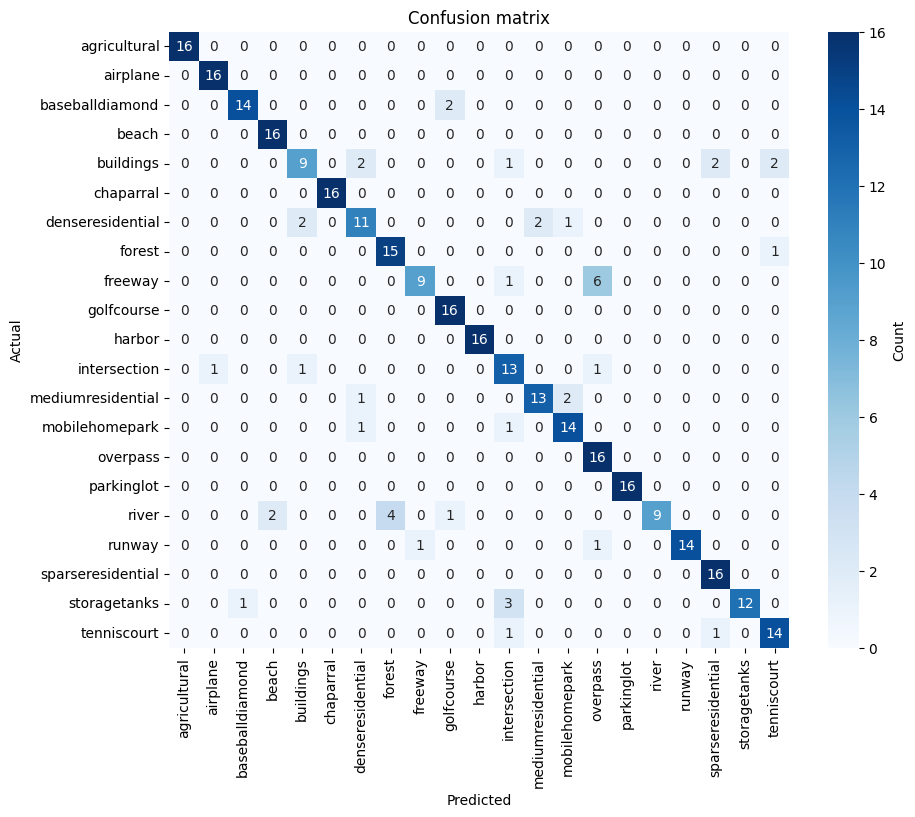

In [12]:
# Plot confusion matrix
# Ensure there is an active wandb run before plotting (cell 16 already called run.finish())
if wandb.run is None:
    wandb.init(mode="disabled", reinit=True)

evaluation.plot_confusion_matrix(model, val_loader, class_names, device, "Confusion matrix")

## Test model on test dataset - Only on best model

In [13]:
test_dataset = SingleLabelDataset(test_df, class_names, transform)
test_loader = DataLoader(test_dataset, batch_size=run.config.batch_size, shuffle=False)

test_precision, test_recall, test_f1, test_p_macro, test_r_macro, test_f1_macro = evaluation.compute_accuracy_metrics_singlelabel(
    model,
    test_loader,
    device
)

print("Test Set Performance")
print(f"Precision (Macro): {test_p_macro:.4f}")
print(f"Recall (Macro):    {test_r_macro:.4f}")
print(f"F1-Score (Macro):  {test_f1_macro:.4f}")

print("\nPer-class metrics:")
for i, class_name in enumerate(class_names):
    print(
        f"{class_name:15} - "
        f"Precision: {test_precision[i]:.4f}, "
        f"Recall: {test_recall[i]:.4f}, "
        f"F1: {test_f1[i]:.4f}"
    )

Test Set Performance
Precision (Macro): 0.8792
Recall (Macro):    0.8571
F1-Score (Macro):  0.8587

Per-class metrics:
agricultural    - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
airplane        - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
baseballdiamond - Precision: 0.9500, Recall: 0.9500, F1: 0.9500
beach           - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
buildings       - Precision: 0.7273, Recall: 0.8000, F1: 0.7619
chaparral       - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
denseresidential - Precision: 0.9333, Recall: 0.7000, F1: 0.8000
forest          - Precision: 0.9091, Recall: 1.0000, F1: 0.9524
freeway         - Precision: 0.9091, Recall: 0.5000, F1: 0.6452
golfcourse      - Precision: 0.8000, Recall: 1.0000, F1: 0.8889
harbor          - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
intersection    - Precision: 0.6667, Recall: 0.8000, F1: 0.7273
mediumresidential - Precision: 0.5769, Recall: 0.7500, F1: 0.6522
mobilehomepark  - Precision: 0.7500, Recall: 0

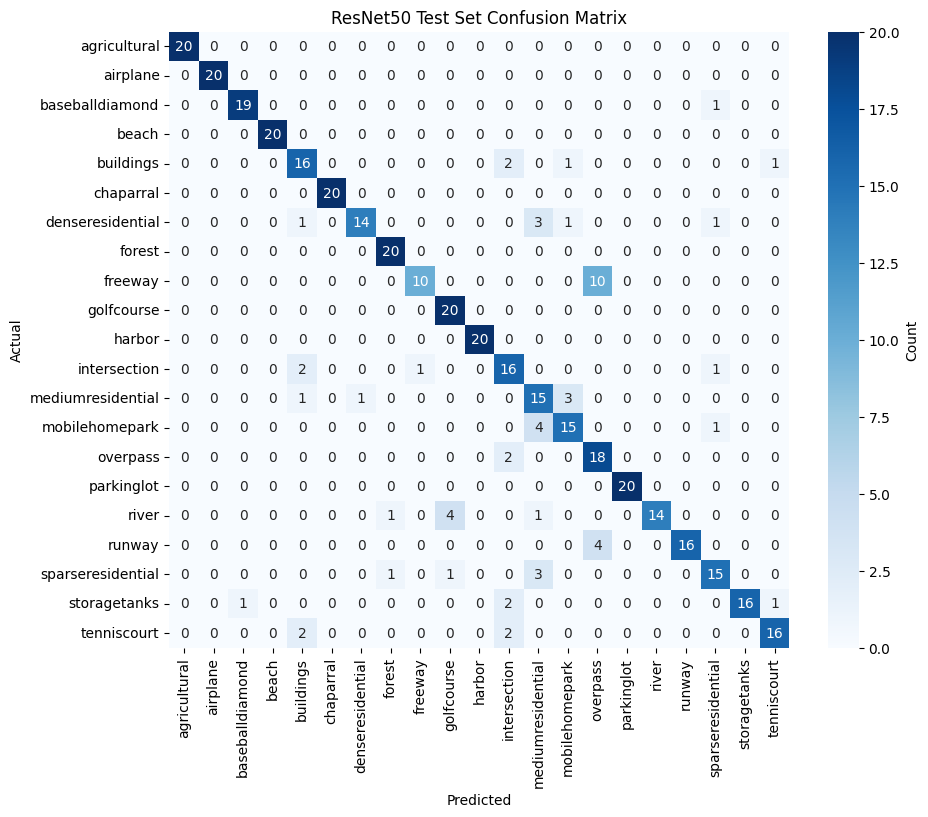

In [14]:
# Plot confusion matrix
# Ensure there is an active wandb run before plotting (cell 16 already called run.finish())
if wandb.run is None:
    wandb.init(mode="disabled", reinit=True)

evaluation.plot_confusion_matrix(model, test_loader, class_names, device, "ResNet50 Test Set Confusion Matrix")